# FoodBridge SG - Donor Surplus Forecast Model
### IS215 Digital Business - Technologies and Transformation

This notebook implements the **donor-facing surplus forecasting pipeline** for FoodBridge SG.  
It takes historical grocery sales data and predicts how much perishable food each store is likely to have as surplus on any given day, enabling supermarket managers (donors) to proactively reduce over-ordering and reduce food wastage through effective distribution.

**Dataset:** Corporación Favorita Grocery Sales (UCI-style supermarket data)  
**Model:** Random Forest Classifier & XGBoost  

---
## Stage 1: Import Libraries

We import the core libraries needed for this pipeline:

- **pandas / numpy** — data loading, manipulation and numerical operations
- **matplotlib / seaborn** — visualisation for EDA and charts
- **scikit-learn** — machine learning tools (model, train/test split, metrics, encoders)
- **warnings** — suppress non-critical deprecation warnings to keep output clean

> If any library is missing, run `pip install pandas numpy scikit-learn matplotlib seaborn` in your terminal first.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Tunable parameters ────────────────────────────────────────────────────
FOOD_PRICE_PER_UNIT = 1.50   # Estimated SGD value per unit of surplus food
DONATION_RATE = 0.07          # 7% of surplus is donated — Source: WRAP UK Food Waste Statistics (2024)

def save_json(data, filename):
    with open(filename, 'w') as f:
        json.dump(data, f, indent=2, default=str)
    print(f"  ✓ Saved: {filename}")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
## Stage 2: Load All CSV Files

We load all 7 source files that make up this dataset.

| File | Contents |
|---|---|
| `training.csv` | Historical daily unit sales per store per item |
| `items.csv` | Item metadata including whether it is perishable |
| `stores.csv` | Store locations, types, and cluster assignments |
| `transactions.csv` | Daily transaction count (customer footfall) per store |
| `oil.csv` | Daily oil price — a macroeconomic demand indicator |
| `holidays_events.csv` | National/regional holidays that affect buying patterns |

All `date` columns are converted to `datetime` type immediately.  
This is essential — without it, date arithmetic (rolling averages, holiday lookups) will fail silently or throw type errors.

In [34]:
print("\n📂 Loading datasets...")

train = pd.read_csv('training.csv')
items = pd.read_csv('items.csv')
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
oil = pd.read_csv('oil.csv')
holidays = pd.read_csv('holidays_events.csv')

# Convert date columns to datetime format
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

print(f"  training.csv     → {train.shape[0]:,} rows")
print(f"  items.csv        → {items.shape[0]:,} rows")
print(f"  stores.csv       → {stores.shape[0]:,} rows")
print(f"  transactions.csv → {transactions.shape[0]:,} rows")
print(f"  oil.csv          → {oil.shape[0]:,} rows")
print(f"  holidays.csv     → {holidays.shape[0]:,} rows")
print("✅ All datasets loaded")


📂 Loading datasets...
  training.csv     → 750,000 rows
  items.csv        → 4,100 rows
  stores.csv       → 54 rows
  transactions.csv → 83,488 rows
  oil.csv          → 1,218 rows
  holidays.csv     → 350 rows
✅ All datasets loaded


---
## Stage 3: Filter for Perishable Items Only

Not all food items go to waste, only **perishable** items (fresh produce, bread, dairy, deli) spoil if unsold.  
The `items.csv` file has a binary `perishable` column: `1 = perishable`, `0 = non-perishable`.

**Why this matters:**  
Including non-perishable items (e.g. canned goods, cleaning products) would dilute the wastage signal and make the model predict wastage for items that cannot go bad, producing meaningless results.

We filter `items` to perishables only, then do an **inner merge** with training data so only perishable item-store-date rows remain in our working dataframe `df`.

In [35]:
perishable_items = items[items['perishable'] == 1][['item_nbr', 'family', 'class']]

print(f"  Total items: {len(items)}")
print(f"  Perishable items: {len(perishable_items)}")
print(f"  Item families: {perishable_items['family'].unique()}")

# Merge train data with perishable items only
df = train.merge(perishable_items, on='item_nbr', how='inner')

print(f"\n  Training rows after filtering to perishables: {df.shape[0]:,}")
print("✅ Perishable filter applied")

# Preview the filtered data
df.head()

  Total items: 4100
  Perishable items: 986
  Item families: <StringArray>
[  'BREAD/BAKERY',           'DELI',        'POULTRY',           'EGGS',
          'DAIRY',          'MEATS',        'SEAFOOD', 'PREPARED FOODS',
        'PRODUCE']
Length: 9, dtype: str

  Training rows after filtering to perishables: 164,928
✅ Perishable filter applied


,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class
0,0,2013-01-01,25,103665,7.0,NaN,BREAD/BAKERY,2712
1,4,2013-01-01,25,108701,1.0,NaN,DELI,2644
2,25,2013-01-01,25,129635,11.0,NaN,DAIRY,2112
3,26,2013-01-01,25,153239,3.0,NaN,BREAD/BAKERY,2712
4,28,2013-01-01,25,153395,7.0,NaN,BREAD/BAKERY,2704


---
## Stage 4: Engineer the Target Variable - Estimated Wastage

The dataset has no direct "wastage" column, so we must **engineer it** as a proxy.

**The core logic:**
> `Estimated Waste = 7-Day Rolling Average Sales − Actual Sales Today`  
> (clipped to 0 as waste can never be negative)

**Why a 7-day rolling average?**  
A 7-day window smooths out weekly seasonal patterns (e.g. busy Fridays) while still being short enough to adapt to recent demand trends. If a store usually sells 10 units but only sold 3 today, the 7 remaining units are likely unsold perishables that will be wasted.

**Why `.shift(1)`?**  
We shift by 1 day so today's actual sales are not included in "today's expected sales", this avoids **data leakage**, where the model would otherwise already know the answer.

**Why `.clip(lower=0)`?**  
If a store sells more than its average (e.g. during a promotion), the difference is negative, but negative waste has no physical meaning, so we floor it at zero.

**Lag features (added after rolling average):**
Five columns give the model item-specific recent history, which the 7-day average alone cannot capture:

- `waste_lag_1` / `waste_lag_7` — yesterday's and last-week's waste for the same store-item. Captures persistence: if an item wasted yesterday, it is likely to waste today.
- `sales_lag_1` — yesterday's actual sales, a more immediate signal than the smoothed 7-day average.
- `avg_sales_14d` — a longer-term baseline. When the 7-day average is below the 14-day average, demand is declining and waste is likely increasing.
- `sales_volatility` — rolling standard deviation of sales. Items with erratic demand are inherently harder to stock correctly and generate more waste.

All lag features use `.shift()` to avoid data leakage (only past data is used). NaNs produced for the first rows of each store-item group are filled with 0.

In [36]:
# Sort data before computing rolling average — essential for correct groupby ordering
df = df.sort_values(['store_nbr', 'item_nbr', 'date']).reset_index(drop=True)

# 7-day rolling average (using prior days only, not today — avoids leakage)
df['avg_sales_7d'] = (
    df.groupby(['store_nbr', 'item_nbr'])['unit_sales']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# Estimated wastage = gap between expected and actual (never negative)
df['estimated_waste'] = (df['avg_sales_7d'] - df['unit_sales']).clip(lower=0)

# Remove rows where rolling average could not be computed (first record per item)
df = df.dropna(subset=['avg_sales_7d'])
# ── Lag features — item-specific recent history ──────────────────────────
df['waste_lag_1'] = df.groupby(['store_nbr', 'item_nbr'])['estimated_waste'].shift(1)
df['waste_lag_7'] = df.groupby(['store_nbr', 'item_nbr'])['estimated_waste'].shift(7)
df['sales_lag_1'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].shift(1)
df['avg_sales_14d'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).mean()
)
df['sales_volatility'] = df.groupby(['store_nbr', 'item_nbr'])['unit_sales'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).std()
)

# Fill NaNs from the first few rows of each store-item group
for col in ['waste_lag_1', 'waste_lag_7', 'sales_lag_1', 'avg_sales_14d', 'sales_volatility']:
    df[col] = df[col].fillna(0)


print(f"  Average estimated waste per row: {df['estimated_waste'].mean():.2f} units")
print(f"  Max estimated waste in one row:  {df['estimated_waste'].max():.2f} units")
print(f"  Rows with non-zero waste: {(df['estimated_waste'] > 0).sum():,}")
print("✅ Wastage target variable created")

df[['store_nbr','item_nbr','date','unit_sales','avg_sales_7d','estimated_waste']].head(10)

  Average estimated waste per row: 2.56 units
  Max estimated waste in one row:  1654.62 units
  Rows with non-zero waste: 86,211
✅ Wastage target variable created


,store_nbr,item_nbr,date,unit_sales,avg_sales_7d,estimated_waste
1,1,103665,2013-01-16,1.0,6.000000,5.000000
2,1,103665,2013-01-17,8.0,3.500000,0.000000
3,1,103665,2013-01-18,3.0,5.000000,2.000000
4,1,103665,2013-01-19,6.0,4.500000,0.000000
5,1,103665,2013-02-01,2.0,4.800000,2.800000
6,1,103665,2013-03-01,3.0,4.333333,1.333333
7,1,103665,2013-04-01,2.0,4.142857,2.142857
8,1,103665,2013-05-01,4.0,3.571429,0.000000
9,1,103665,2013-06-01,2.0,4.000000,2.000000
10,1,103665,2013-07-01,1.0,3.142857,2.142857


---
## Stage 5: Feature Engineering — Add External Signals

A model that only sees `avg_sales_7d` would miss important context about *why* waste spikes.  
We enrich the dataset with 6 categories of features:

| Feature group | Features added | Why it matters |
|---|---|---|
| **Date** | day_of_week, month, day_of_month, is_weekend | Wastage is higher on certain days (e.g. Monday after low-traffic weekend) |
| **Holidays** | is_holiday, is_day_after_holiday | Stores over-order before holidays; the day after sees high unsold stock |
| **Oil price** | dcoilwtico | Proxy for economic conditions — lower purchasing power → lower sales → more waste |
| **Footfall** | transactions | Fewer customers = more unsold stock at end of day |
| **Store info** | type, city, cluster | Different store formats and locations have different waste profiles |
| **Item** | family_encoded, onpromotion | Promotions boost sales; item family determines perishability pattern |

**Categorical encoding:**  
Machine learning models require numeric inputs. We use `LabelEncoder` to convert `family`, `city`, and `type` from text labels into integer codes.

**Note on `reindex` in EDA charts (Stage 6):**  
After this merge, `is_holiday` is guaranteed to have both 0 and 1 values — but if data is filtered, one value might be absent. We use `.reindex()` in charts to guard against shape mismatches.

In [37]:
print("\n🔧 Engineering features...")

# 5a. Date features
df['day_of_week']  = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['month']        = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

# 5b. Holiday flags
# Use .assign() to avoid chained-assignment warning on a filtered slice
national_holidays = holidays[
    (holidays['locale'] == 'National') & (holidays['type'] == 'Holiday')
][['date']].drop_duplicates().assign(is_holiday=1)

# Drop column first so re-running the cell doesn't produce duplicate is_holiday_x / is_holiday_y
df = df.drop(columns=['is_holiday'], errors='ignore')
df = df.merge(national_holidays, on='date', how='left')
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)

holiday_dates = set(national_holidays['date'])
df['is_day_after_holiday'] = df['date'].apply(
    lambda d: 1 if (d - pd.Timedelta(days=1)) in holiday_dates else 0
)

# 5c. Oil price (forward-fill gaps on weekends/public holidays)
oil = oil.sort_values('date')
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()
df = df.drop(columns=['dcoilwtico'], errors='ignore')
df = df.merge(oil, on='date', how='left')
df['dcoilwtico'] = df['dcoilwtico'].fillna(df['dcoilwtico'].median())

# 5d. Customer footfall
df = df.drop(columns=['transactions'], errors='ignore')
df = df.merge(transactions, on=['date', 'store_nbr'], how='left')
df['transactions'] = df['transactions'].fillna(df['transactions'].median())

# 5e. Store metadata
df = df.drop(columns=['city', 'type', 'cluster'], errors='ignore')
df = df.merge(stores[['store_nbr', 'city', 'type', 'cluster']], on='store_nbr', how='left')

# 5f. Encode categoricals → numeric for ML
le = LabelEncoder()
df['family_encoded'] = le.fit_transform(df['family'].astype(str))
df['city_encoded']   = le.fit_transform(df['city'].astype(str))
df['type_encoded']   = le.fit_transform(df['type'].astype(str))
df['onpromotion']    = df['onpromotion'].fillna(0).astype(int)

print("  Features added:")
print("    ✔ day_of_week, month, day_of_month, is_weekend")
print("    ✔ is_holiday, is_day_after_holiday")
print("    ✔ oil price (dcoilwtico)")
print("    ✔ store transactions (footfall)")
print("    ✔ store type, city, cluster")
print("    ✔ item family, onpromotion")
print("✅ Feature engineering complete — final shape:", df.shape)


🔧 Engineering features...
  Features added:
    ✔ day_of_week, month, day_of_month, is_weekend
    ✔ is_holiday, is_day_after_holiday
    ✔ oil price (dcoilwtico)
    ✔ store transactions (footfall)
    ✔ store type, city, cluster
    ✔ item family, onpromotion
✅ Feature engineering complete — final shape: (154198, 29)


---
## Stage 6: Exploratory Data Analysis (EDA)

Before training the model, we visualise the data to understand **where and when waste occurs**.  
These charts allow us to identify potential drivers in fod surplus, as well as validate the correlation between the 14 features and surplus.

**Chart 1 - Wastage by item family:** Identifies which food categories waste the most, guiding NPO collection priorities.  
**Chart 2 - Holiday impact:** Shows whether holidays cause above-average waste - validating our `is_holiday` feature.  
**Chart 3 - Day of week pattern:** Reveals if certain days consistently have more unsold stock.  
**Chart 4 - Store type comparison:** Shows if supermarket format (A/B/C/D/E) affects waste levels.

> `.reindex()` is used on charts 2 and 3 to ensure all expected categories always exist in the grouped result, preventing a `ValueError: shape mismatch` if any group is empty.


📊 Generating EDA charts...


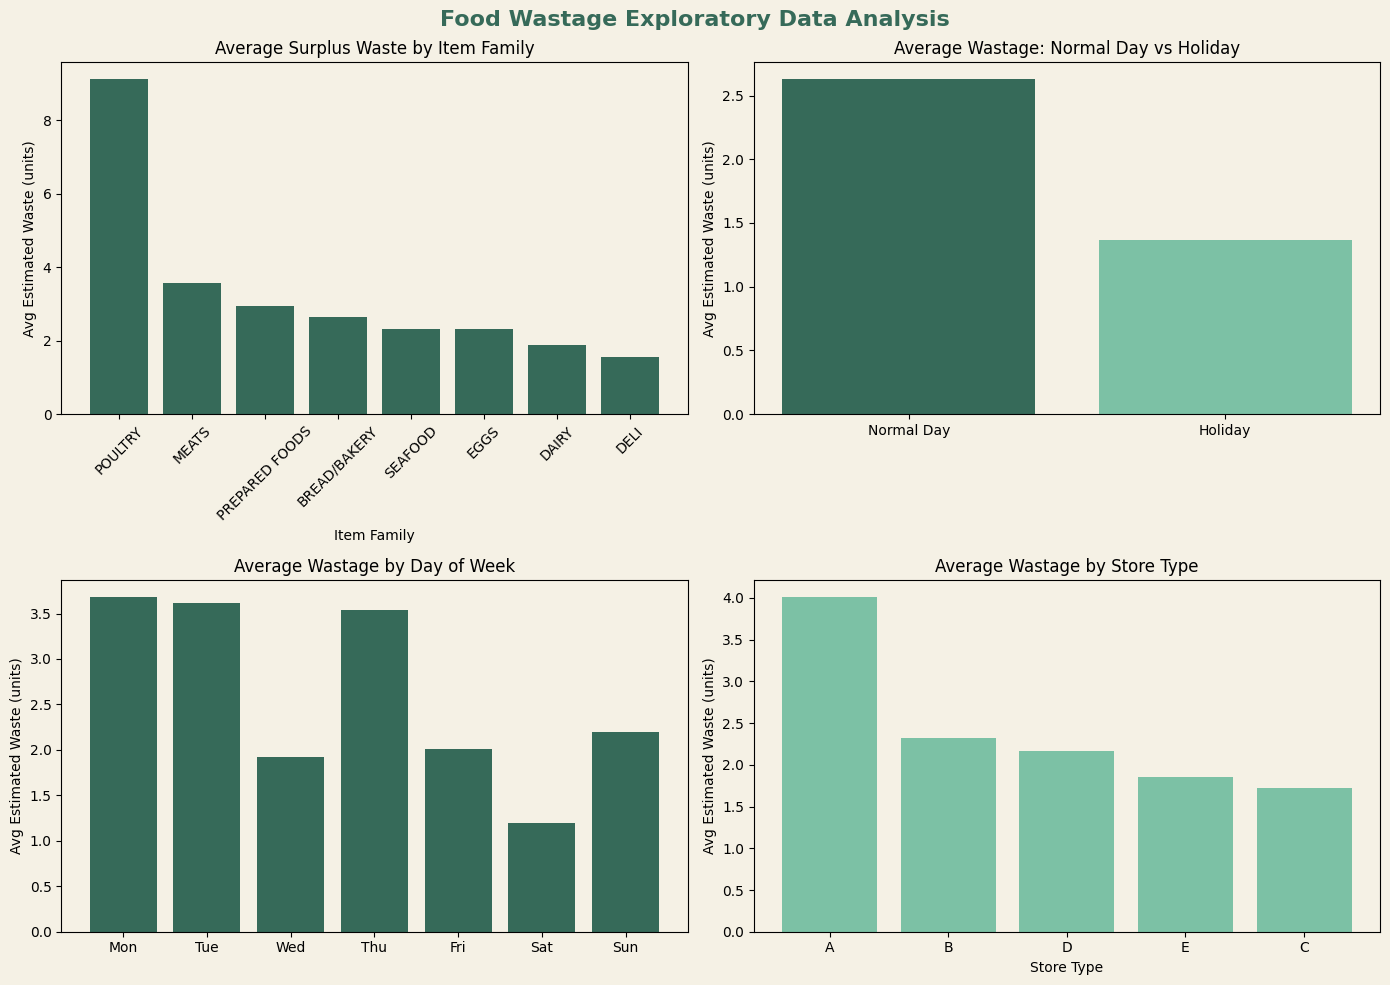

  📁 Saved: eda_charts.png
✅ EDA complete


In [76]:
print("\n📊 Generating EDA charts...")

# Added facecolor to blend seamlessly with the slide's beige background
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#F5F1E5')
fig.suptitle('Food Wastage Exploratory Data Analysis', fontsize=16, fontweight='bold', color='#366A59')

# Apply beige background to all individual subplots
for ax in axes.flat:
    ax.set_facecolor('#F5F1E5')

# Chart 1: Average estimated waste per item family
waste_by_family = df.groupby('family')['estimated_waste'].mean().sort_values(ascending=False)
axes[0, 0].bar(waste_by_family.index, waste_by_family.values, color='#366A59') # Dark Teal
axes[0, 0].set_title('Average Surplus Waste by Item Family')
axes[0, 0].set_xlabel('Item Family')
axes[0, 0].set_ylabel('Avg Estimated Waste (units)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Chart 2: Holiday vs normal day — reindex guards against missing groups
waste_by_holiday = (
    df.groupby('is_holiday')['estimated_waste']
    .mean()
    .reindex([0, 1], fill_value=0)
)
# Using Dark Teal for Normal, Light Mint for Holiday
axes[0, 1].bar(['Normal Day', 'Holiday'], waste_by_holiday.values, color=['#366A59', '#7CC1A5']) 
axes[0, 1].set_title('Average Wastage: Normal Day vs Holiday')
axes[0, 1].set_ylabel('Avg Estimated Waste (units)')

# Chart 3: Day of week — reindex ensures all 7 days always appear
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
waste_by_dow = (
    df.groupby('day_of_week')['estimated_waste']
    .mean()
    .reindex(range(7), fill_value=0)
)
axes[1, 0].bar(day_names, waste_by_dow.values, color='#366A59') # Dark Teal
axes[1, 0].set_title('Average Wastage by Day of Week')
axes[1, 0].set_ylabel('Avg Estimated Waste (units)')

# Chart 4: Store type
waste_by_type = df.groupby('type')['estimated_waste'].mean().sort_values(ascending=False)
axes[1, 1].bar(waste_by_type.index, waste_by_type.values, color='#7CC1A5') # Light Mint for variety
axes[1, 1].set_title('Average Wastage by Store Type')
axes[1, 1].set_xlabel('Store Type')
axes[1, 1].set_ylabel('Avg Estimated Waste (units)')

plt.tight_layout()
# Ensured savefig captures the new beige background
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor()) 
plt.show()
print("  📁 Saved: eda_charts.png")
print("✅ EDA complete")

---
## Stage 7: Train the Machine Learning Model

We use a **two-stage model** to predict `estimated_waste` because ~45% of rows have zero waste. A single regressor wastes half its capacity learning "when waste is zero" instead of "how much waste occurs."

**Stage A — Random Forest Classifier:**  
Predicts whether waste will occur at all (binary: 1 = waste, 0 = no waste). This preserves the model's ability to correctly predict zero waste for well-calibrated stores. Uses the full dataset.

**Stage B — XGBoost Regressor:**  
Trained **only on non-zero rows** with `np.log1p()`-transformed targets. XGBoost was chosen over Random Forest because it builds trees **sequentially** — each new tree specifically targets the prediction errors of previous trees (gradient boosting). This makes it better at predicting rare high-waste events that Random Forest's averaging tends to underpredict.

**XGBoost hyperparameters:**
- `n_estimators=300` — more trees than RF because each boosting tree is shallower and more specialised
- `max_depth=8` — shallower than RF (which used 20) because boosting compensates with sequential correction; deep trees in boosting overfit
- `learning_rate=0.1` — controls how much each tree contributes; lower values generalise better but need more trees
- `subsample=0.8` / `colsample_bytree=0.8` — each tree sees 80% of rows and 80% of features, adding randomness to prevent overfitting (similar to Random Forest's bagging)
- `reg_alpha=0.1` / `reg_lambda=1.0` — L1 and L2 regularisation to penalise overly complex trees

**`two_stage_predict(X)`:**  
A helper function defined here and used by all downstream cells. Runs Stage A (classifier gate), Stage B (XGBoost quantity prediction), applies `np.expm1()` to convert back from log space, and returns original-unit predictions. All downstream cells use this single function for consistent, correct predictions.

In [83]:
print("\n🤖 Training two-stage wastage forecasting model...")
print("  Stage A: Classifier (Random Forest) — will waste occur?")
print("  Stage B: Regressor  (XGBoost)       — if yes, how much?\n")

FEATURES = [
    'day_of_week', 'month', 'day_of_month', 'is_weekend',
    'is_holiday', 'is_day_after_holiday',
    'onpromotion', 'dcoilwtico', 'transactions',
    'type_encoded', 'cluster', 'city_encoded',
    'family_encoded', 'avg_sales_7d',
    # Lag features — item-specific recent history
    'waste_lag_1', 'waste_lag_7', 'sales_lag_1',
    'avg_sales_14d', 'sales_volatility'
]

X = df[FEATURES]

# ── Stage A: Classifier — will waste occur? ───────────────────────────────
y_class = (df['estimated_waste'] > 0).astype(int)

X_train, X_test, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
classifier.fit(X_train, y_train_class)

y_pred_class = classifier.predict(X_test)
cls_accuracy = accuracy_score(y_test_class, y_pred_class)
cls_f1 = f1_score(y_test_class, y_pred_class)
cls_recall = recall_score(y_test_class, y_pred_class)

print(f"  Stage A — Classifier Performance:")
print(f"     Accuracy:  {cls_accuracy:.3f}")
print(f"     Recall:    {cls_recall:.3f} ")
print(f"     F1 Score:  {cls_f1:.3f}")

# ── Stage B: XGBoost Regressor on NON-ZERO rows only ─────────────────────
df_nonzero = df[df['estimated_waste'] > 0].copy()
X_nz = df_nonzero[FEATURES]
y_nz_log = np.log1p(df_nonzero['estimated_waste'])

X_train_nz, X_test_nz, y_train_nz_log, y_test_nz_log = train_test_split(
    X_nz, y_nz_log, test_size=0.2, random_state=42
)

regressor = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
regressor.fit(X_train_nz, y_train_nz_log)

y_pred_nz_log = regressor.predict(X_test_nz)
y_pred_nz = np.expm1(y_pred_nz_log).clip(min=0)
y_test_nz = np.expm1(y_test_nz_log)

from sklearn.metrics import r2_score
reg_r2 = r2_score(y_test_nz, y_pred_nz)
reg_mae = mean_absolute_error(y_test_nz, y_pred_nz)

print(f"\n  Stage B \u2014 XGBoost Regressor Performance (non-zero rows only):")
print(f"     MAE:  {reg_mae:.2f} units")
print(f"     R\u00b2:   {reg_r2:.3f}")
print(f"     Trained on {len(df_nonzero):,} non-zero rows ({len(df_nonzero)/len(df)*100:.1f}% of data)")

# ── Two-stage prediction helper ───────────────────────────────────────────
def two_stage_predict(X_input):
    """
    Two-stage prediction:
    1. Classifier decides if waste occurs (0 or 1)
    2. For rows predicted as 1, XGBoost predicts quantity (log space -> expm1)
    3. Rows predicted as 0 get waste = 0
    Returns predictions in original units.
    """
    X_df = pd.DataFrame(X_input, columns=FEATURES) if not isinstance(X_input, pd.DataFrame) else X_input.copy()
    X_df = X_df[FEATURES]  # ensure correct column order
    preds = np.zeros(len(X_df))
    will_waste = classifier.predict(X_df) == 1
    if will_waste.sum() > 0:
        preds[will_waste] = np.expm1(regressor.predict(X_df[will_waste])).clip(min=0)
    return preds

# ── Combined evaluation on full test set ──────────────────────────────────
y_pred = two_stage_predict(X_test)
y_test = df.loc[X_test.index, 'estimated_waste'].values

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n  \U0001f4c8 Combined Two-Stage Performance (full test set):")
print(f"     MAE:  {mae:.2f} units")
print(f"     RMSE: {rmse:.2f} units")
print(f"     R\u00b2:   {r2:.3f}")
print("\u2705 Two-stage model trained (Random Forest Classifier + XGBoost)")


🤖 Training two-stage wastage forecasting model...
  Stage A: Classifier (Random Forest) — will waste occur?
  Stage B: Regressor  (XGBoost)       — if yes, how much?

  Stage A — Classifier Performance:
     Accuracy:  0.658
     Recall:    0.772 
     F1 Score:  0.715

  Stage B — XGBoost Regressor Performance (non-zero rows only):
     MAE:  2.23 units
     R²:   0.754
     Trained on 86,211 non-zero rows (55.9% of data)

  📈 Combined Two-Stage Performance (full test set):
     MAE:  1.73 units
     RMSE: 5.00 units
     R²:   0.571
✅ Two-stage model trained (Random Forest Classifier + XGBoost)


---
## Stage 8: Feature Importance — What Drives Surplus?

Random Forest tracks how much each feature reduces prediction error across all trees.  
This gives us a ranked **feature importance** score — the higher the score, the more that feature contributes to accurate surplus predictions.

**Why this matters for the project:**
- Features with high importance are the key levers stores can monitor to reduce waste
- For example, if `avg_sales_7d` ranks highest, it confirms that past demand is the strongest predictor — which validates the rolling average approach
- If `is_holiday` ranks highly, it confirms that stores should adjust orders around holidays


🔍 Analysing feature importance...


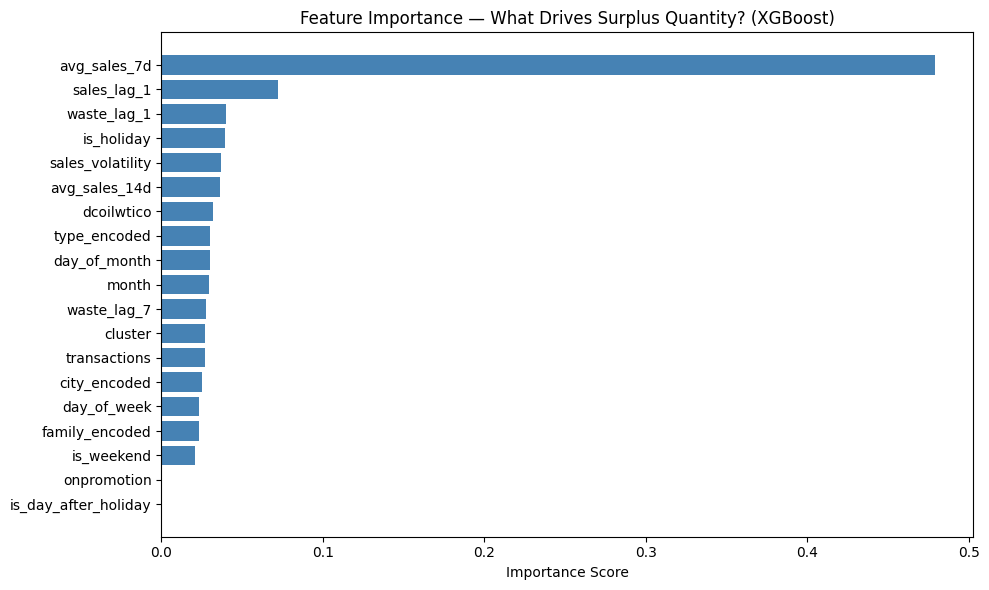

  📁 Saved: feature_importance.png

  Top 3 drivers of surplus:
     avg_sales_7d: 0.479
     sales_lag_1: 0.072
     waste_lag_1: 0.040


In [52]:
print("\n🔍 Analysing feature importance...")

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': regressor.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — What Drives Surplus Quantity? (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("  📁 Saved: feature_importance.png")
print(f"\n  Top 3 drivers of surplus:")
for _, row in importance_df.head(3).iterrows():
    print(f"     {row['feature']}: {row['importance']:.3f}")

---
## Stage 8b: Model Validation

Before using the model to generate forecasts, we validate its performance on the held-out test set using three complementary approaches:

1. **Metrics** — MAE, RMSE (already computed in Stage 7), plus R² score which measures what proportion of variance in waste the model explains (1.0 = perfect, 0.0 = no better than predicting the mean)
2. **Actual vs Predicted scatter plot** — points should cluster along the diagonal line; spread away from the line indicates prediction error
3. **Residuals analysis** — the distribution of errors should be bell-shaped and centered near zero (unbiased); the residuals-vs-predicted plot should show no pattern (homoscedastic errors)

These checks confirm the model is reliable enough for operational use before we feed its outputs to the donor dashboard.

**Donation Rate:** This notebook uses a **7% donation rate** — the percentage of total food surplus that gets successfully redistributed. This is based on the UK Waste & Resources Action Programme (WRAP) finding that only 7% of retail food surplus is currently being redistributed (Food Waste Statistics, 2024). Not all surplus can be rescued: some spoils before collection, some fails quality checks, and logistics constraints limit what NPOs can physically collect.


🔍 Validating model performance...


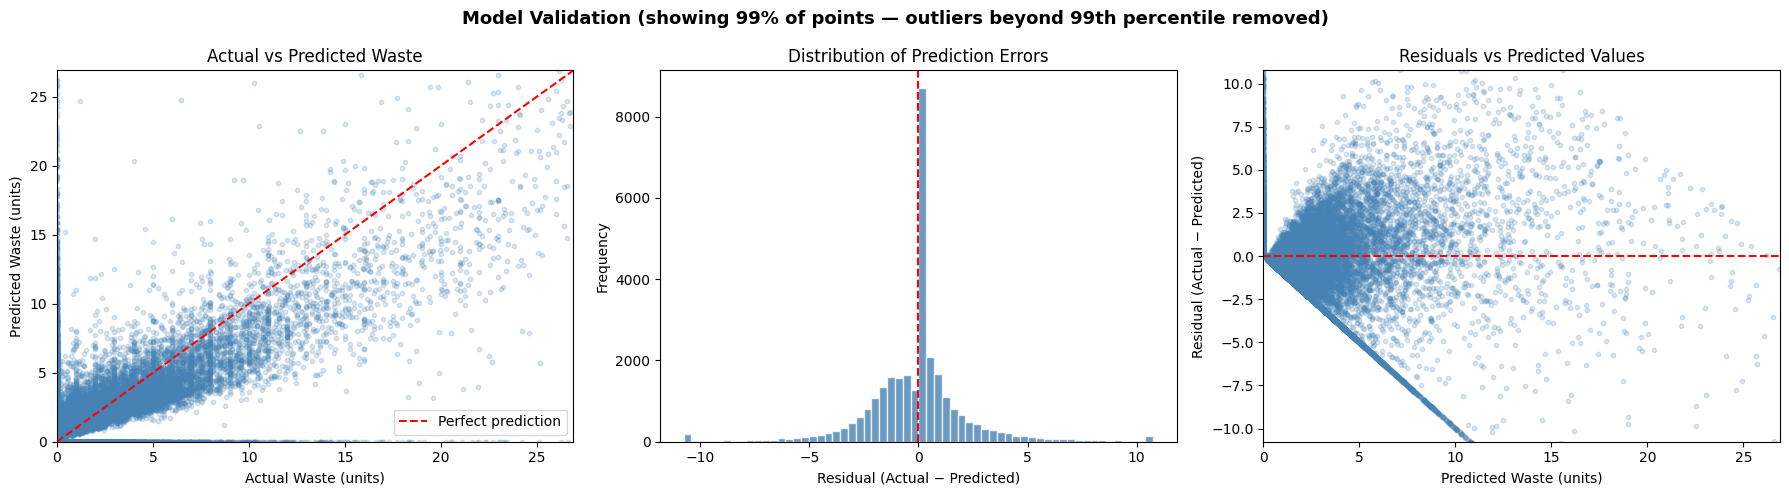

  📁 Saved: model_validation.png

  Model Validation Summary:
     MAE:  1.73 units (average error per prediction)
     RMSE: 5.00 units (penalises large errors)
     R²:   0.571 (proportion of variance explained)
     Note: metrics computed on full test set; plots clip at 99th percentile (27 units)
     ⚠️ Model has moderate explanatory power — use forecasts directionally
✅ Model validation complete


In [82]:
from sklearn.metrics import r2_score

print("\n🔍 Validating model performance...")

r2 = r2_score(y_test, y_pred)
residuals = y_test - y_pred

# ── Remove outliers for cleaner visualisation (keep full data for metrics) ──
# Use IQR-based clipping at 99th percentile so extreme rare spikes don't
# compress the meaningful bulk of the distribution into one corner
p99_actual = np.percentile(y_test, 99)
p99_pred   = np.percentile(y_pred, 99)
p99_resid  = np.percentile(np.abs(residuals), 99)
plot_cap   = max(p99_actual, p99_pred)

mask = (y_test <= plot_cap) & (y_pred <= plot_cap)
y_test_plot  = y_test[mask]
y_pred_plot  = y_pred[mask]
resid_plot   = residuals[mask]
resid_cap    = np.percentile(np.abs(resid_plot), 99)

pct_shown = mask.sum() / len(mask) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Model Validation (showing {pct_shown:.0f}% of points — outliers beyond 99th percentile removed)',
             fontsize=13, fontweight='bold')

# 1. Actual vs Predicted scatter
axes[0].scatter(y_test_plot, y_pred_plot, alpha=0.2, s=10, color='steelblue')
axes[0].plot([0, plot_cap], [0, plot_cap], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlim(0, plot_cap)
axes[0].set_ylim(0, plot_cap)
axes[0].set_xlabel('Actual Waste (units)')
axes[0].set_ylabel('Predicted Waste (units)')
axes[0].set_title('Actual vs Predicted Waste')
axes[0].legend()

# 2. Residuals histogram
axes[1].hist(resid_plot.clip(-resid_cap, resid_cap), bins=60,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual \u2212 Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Errors')

# 3. Residuals vs Predicted
axes[2].scatter(y_pred_plot, resid_plot, alpha=0.2, s=10, color='steelblue')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlim(0, plot_cap)
axes[2].set_ylim(-resid_cap, resid_cap)
axes[2].set_xlabel('Predicted Waste (units)')
axes[2].set_ylabel('Residual (Actual \u2212 Predicted)')
axes[2].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.savefig('model_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("  \U0001f4c1 Saved: model_validation.png")

print(f"\n  Model Validation Summary:")
print(f"     MAE:  {mae:.2f} units (average error per prediction)")
print(f"     RMSE: {rmse:.2f} units (penalises large errors)")
print(f"     R\u00b2:   {r2:.3f} (proportion of variance explained)")
print(f"     Note: metrics computed on full test set; plots clip at 99th percentile ({plot_cap:.0f} units)")
if r2 > 0.7:
    print("     \u2705 Model explains a good proportion of variance \u2014 suitable for forecasting")
elif r2 > 0.4:
    print("     \u26a0\ufe0f Model has moderate explanatory power \u2014 use forecasts directionally")
else:
    print("     \u26a0\ufe0f Model has limited explanatory power \u2014 interpret forecasts with caution")
print("\u2705 Model validation complete")

---
## Stage 9: Generate Donor Surplus Forecast

With the trained model, we predict surplus for the **most recent date** in the dataset and aggregate it to the **store level** — answering the key question for each supermarket manager:

> *"How much surplus am I predicted to have tomorrow, and which product category is the biggest contributor?"*

**Aggregation logic:**
- `total_predicted_waste` — sum of predicted surplus across all perishable items at that store
- `top_waste_category` — the item family with the highest predicted surplus (e.g. BREAD/BAKERY)

**Surplus classification for donors:**
| Level | Threshold | Action for Store Manager |
|---|---|---|
| 🔴 HIGH | ≥ 30 units | Reduce tomorrow's order or arrange donation pickup |
| 🟡 MODERATE | 10–29 units | Review ordering quantities |
| 🟢 LOW | < 10 units | Ordering is well-calibrated |

The output is saved as `donor_surplus_forecast.csv` — this file feeds directly into the donor-facing dashboard and can also be consumed by the beneficiary matching engine.

In [54]:
print("\n🗺️  Generating Donor Surplus Forecast...")

latest_date = df['date'].max()
print(f"  Forecasting for: {latest_date.date()}")

today_df = df[df['date'] == latest_date].copy()

if len(today_df) == 0:
    recent = df[df['date'] >= latest_date - pd.Timedelta(days=7)]
    today_df = recent.groupby(['store_nbr', 'family']).last().reset_index()

today_df['predicted_waste'] = two_stage_predict(today_df[FEATURES])
today_df['predicted_waste'] = today_df['predicted_waste'].clip(lower=0).round(1)

donor_view = (
    today_df.groupby('store_nbr')
    .agg(
        total_predicted_waste=('predicted_waste', 'sum'),
        top_waste_category=('family', lambda x: today_df.loc[x.index]
                            .groupby('family')['predicted_waste']
                            .sum().idxmax())
    )
    .reset_index()
)

donor_view = donor_view.merge(
    stores[['store_nbr', 'city', 'state', 'type']], on='store_nbr', how='left'
)
donor_view = donor_view.sort_values('total_predicted_waste', ascending=False)

def classify_surplus(waste):
    if waste >= 30:   return '🔴 HIGH surplus predicted — consider reducing tomorrow\'s order or arranging donation pickup'
    elif waste >= 10: return '🟡 MODERATE surplus predicted — review ordering quantities'
    else:             return '🟢 LOW surplus predicted — ordering is well-calibrated'

donor_view['surplus_status'] = donor_view['total_predicted_waste'].apply(classify_surplus)
donor_view['forecast_date']  = latest_date.date()

donor_view = donor_view[[
    'forecast_date', 'store_nbr', 'city', 'state', 'type',
    'total_predicted_waste', 'top_waste_category', 'surplus_status'
]]

donor_view.to_csv('donor_surplus_forecast.csv', index=False)
print("  📁 Saved: donor_surplus_forecast.csv")
print("✅ Donor Surplus Forecast generated\n")
donor_view.head(10)


🗺️  Generating Donor Surplus Forecast...
  Forecasting for: 2013-12-01
  📁 Saved: donor_surplus_forecast.csv
✅ Donor Surplus Forecast generated



,forecast_date,store_nbr,city,state,type,total_predicted_waste,top_waste_category,surplus_status
19,2013-12-01,23,Ambato,Tungurahua,D,1358.9,MEATS,🔴 HIGH surplus predicted — consider reducing t...
39,2013-12-01,46,Quito,Pichincha,A,800.7,MEATS,🔴 HIGH surplus predicted — consider reducing t...
41,2013-12-01,48,Quito,Pichincha,A,740.6,POULTRY,🔴 HIGH surplus predicted — consider reducing t...
6,2013-12-01,7,Quito,Pichincha,D,679.8,MEATS,🔴 HIGH surplus predicted — consider reducing t...
8,2013-12-01,9,Quito,Pichincha,B,600.2,POULTRY,🔴 HIGH surplus predicted — consider reducing t...
5,2013-12-01,6,Quito,Pichincha,D,556.7,POULTRY,🔴 HIGH surplus predicted — consider reducing t...
3,2013-12-01,4,Quito,Pichincha,D,530.8,DAIRY,🔴 HIGH surplus predicted — consider reducing t...
10,2013-12-01,11,Cayambe,Pichincha,B,504.4,MEATS,🔴 HIGH surplus predicted — consider reducing t...
0,2013-12-01,1,Quito,Pichincha,D,477.7,DAIRY,🔴 HIGH surplus predicted — consider reducing t...
40,2013-12-01,47,Quito,Pichincha,A,474.4,BREAD/BAKERY,🔴 HIGH surplus predicted — consider reducing t...


---
## Stage 10: Visualise the Donor Surplus Forecast

We produce two charts to make the surplus forecast visually actionable for store managers:

**Left chart — Top Stores by Predicted Surplus (Donor View):**  
Colour-coded by urgency (red/orange/green), this lets each supermarket's operations team instantly see which stores are predicted to have the most surplus and need to take action — either by reducing tomorrow's orders or by proactively arranging a donation pickup with an NPO.

**Right chart — Predicted Surplus by Item Family:**  
Shows the composition of tomorrow's predicted surplus across all stores — helping procurement teams pinpoint which product categories are consistently over-ordered.


📊 Plotting Donor Surplus Forecast Dashboard...


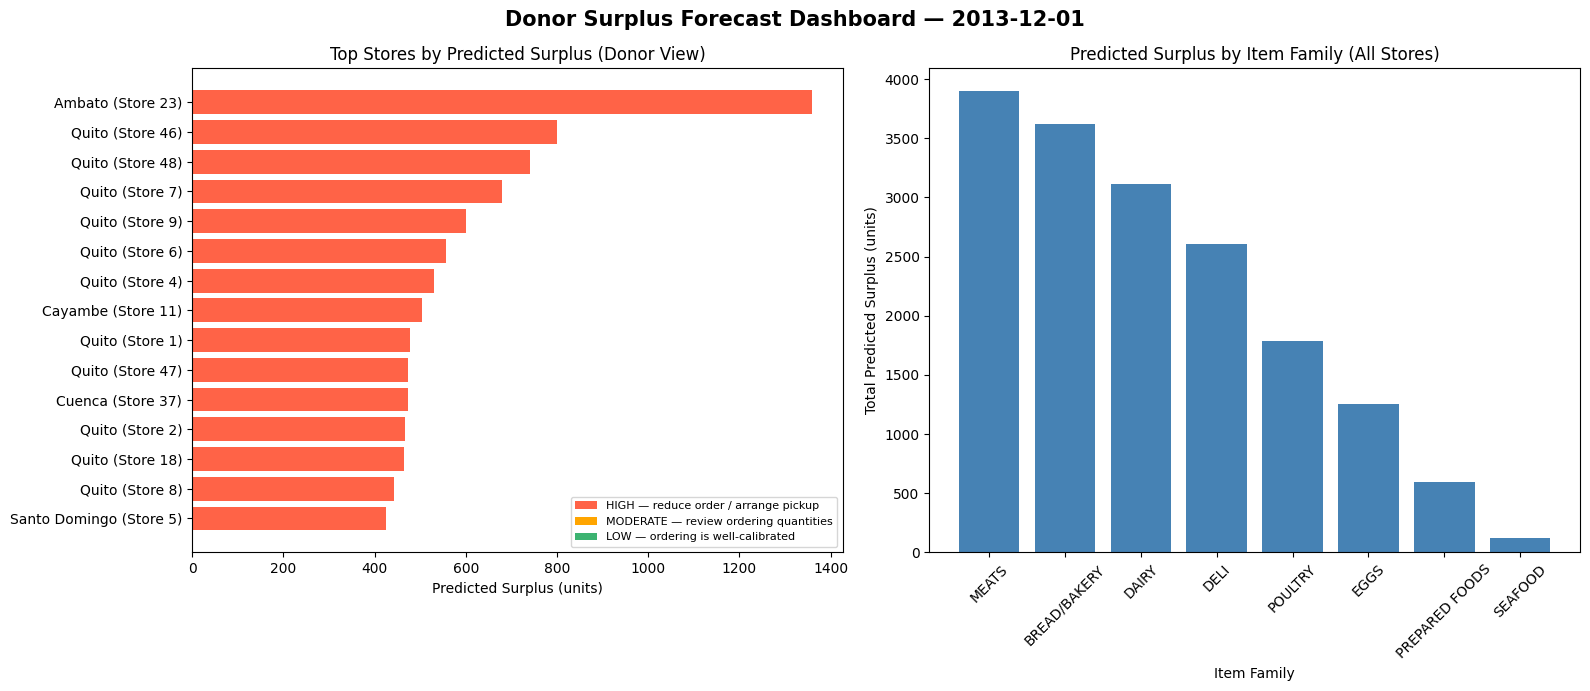

  📁 Saved: donor_dashboard.png
✅ Pipeline complete — donor_surplus_forecast.csv is ready for the donor-facing dashboard


In [55]:
from matplotlib.patches import Patch

print("\n📊 Plotting Donor Surplus Forecast Dashboard...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Donor Surplus Forecast Dashboard — {latest_date.date()}',
             fontsize=15, fontweight='bold')

top_stores = donor_view.head(15)
colors = [
    'tomato'          if '🔴' in s else
    'orange'          if '🟡' in s else
    'mediumseagreen'
    for s in top_stores['surplus_status']
]
axes[0].barh(
    top_stores['city'] + ' (Store ' + top_stores['store_nbr'].astype(str) + ')',
    top_stores['total_predicted_waste'],
    color=colors
)
axes[0].set_xlabel('Predicted Surplus (units)')
axes[0].set_title('Top Stores by Predicted Surplus (Donor View)')
axes[0].invert_yaxis()
axes[0].legend(handles=[
    Patch(facecolor='tomato',         label='HIGH — reduce order / arrange pickup'),
    Patch(facecolor='orange',         label='MODERATE — review ordering quantities'),
    Patch(facecolor='mediumseagreen', label='LOW — ordering is well-calibrated')
], loc='lower right', fontsize=8)

waste_by_family_today = (
    today_df.groupby('family')['predicted_waste']
    .sum().sort_values(ascending=False).head(10)
)
axes[1].bar(waste_by_family_today.index, waste_by_family_today.values, color='steelblue')
axes[1].set_title('Predicted Surplus by Item Family (All Stores)')
axes[1].set_xlabel('Item Family')
axes[1].set_ylabel('Total Predicted Surplus (units)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('donor_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("  📁 Saved: donor_dashboard.png")
print("✅ Pipeline complete — donor_surplus_forecast.csv is ready for the donor-facing dashboard")

---
## Stage 11: Donor Dashboard Metrics

Before drawing charts we compute the headline numbers that appear as metric cards on the donor dashboard.

- **Total predicted surplus (next 30 days):** We apply the trained model to all feature rows in the last 30-day window and sum the predicted waste. This gives the store a forward-looking KPI they can act on — if it is trending up, they should review upcoming orders.
- **Total units donated ($ value):** Multiplies total predicted surplus units by `FOOD_PRICE_PER_UNIT` to give a monetary figure. Communicating waste in dollars rather than units is more impactful for management reporting.
- **Week-over-week % change:** Compares the most recent 7 days of *actual* estimated waste against the prior 7 days. A positive number means waste is rising — a red flag for the store manager.
- **Month-over-month % change:** Same logic over a 30-day window — useful for monthly performance reviews.

In [56]:
print("\n📊 Computing donor dashboard metrics...")

# ── Time windows ──────────────────────────────────────────────────────────
latest_date = df['date'].max()
date_30_ago = latest_date - pd.Timedelta(days=30)
date_60_ago = latest_date - pd.Timedelta(days=60)
date_7_ago  = latest_date - pd.Timedelta(days=7)
date_14_ago = latest_date - pd.Timedelta(days=14)

# ── Daily totals of actual estimated waste (all stores, all perishables) ──
daily_actual = (
    df.groupby('date')['estimated_waste']
    .sum()
    .reset_index()
    .rename(columns={'estimated_waste': 'actual_waste'})
)

# ── Total predicted surplus next 30 days (model applied to last-30-day rows) ──
recent_for_pred = df[df['date'] >= date_30_ago].copy()
recent_for_pred['predicted_waste'] = two_stage_predict(recent_for_pred[FEATURES])
total_predicted_30d = recent_for_pred['predicted_waste'].sum()
total_predicted_30d_value = round(total_predicted_30d * FOOD_PRICE_PER_UNIT, 2)

# ── Total units donated ($ value) — actual waste in last 30 days ──────────
actual_last_30 = daily_actual[daily_actual['date'] >= date_30_ago]['actual_waste'].sum()
total_donated_value = round(actual_last_30 * FOOD_PRICE_PER_UNIT, 2)

# ── Week-over-week % change ────────────────────────────────────────────────
waste_this_week  = daily_actual[daily_actual['date'] >= date_7_ago]['actual_waste'].sum()
waste_prior_week = daily_actual[
    (daily_actual['date'] >= date_14_ago) & (daily_actual['date'] < date_7_ago)
]['actual_waste'].sum()
wow_change = round((waste_this_week - waste_prior_week) / waste_prior_week * 100, 1) if waste_prior_week > 0 else 0

# ── Month-over-month % change ──────────────────────────────────────────────
waste_this_month  = daily_actual[daily_actual['date'] >= date_30_ago]['actual_waste'].sum()
waste_prior_month = daily_actual[
    (daily_actual['date'] >= date_60_ago) & (daily_actual['date'] < date_30_ago)
]['actual_waste'].sum()
mom_change = round((waste_this_month - waste_prior_month) / waste_prior_month * 100, 1) if waste_prior_month > 0 else 0

print(f"  Total predicted surplus (30d):  {total_predicted_30d:,.0f} units  (${total_predicted_30d_value:,.2f})")
print(f"  Total donated value (30d):      ${total_donated_value:,.2f}")
print(f"  Week-over-week change:          {'+' if wow_change >= 0 else ''}{wow_change}%")
print(f"  Month-over-month change:        {'+' if mom_change >= 0 else ''}{mom_change}%")
print("✅ Donor metrics computed")


📊 Computing donor dashboard metrics...
  Total predicted surplus (30d):  46,782 units  ($70,173.20)
  Total donated value (30d):      $58,290.89
  Week-over-week change:          +0%
  Month-over-month change:        +0%
✅ Donor metrics computed


---
## Stage 12: Actual vs Predicted Waste - Trend Line (Past 30 Days)

This chart answers: *"How well does our model track reality day-by-day?"*

- The **blue line** is actual observed waste (the rolling-average proxy `estimated_waste` summed across all stores daily)
- The **orange dashed line** is what the Random Forest model predicted for those same days

**Why show both?**  
If actual waste consistently exceeds predicted waste, the model is underestimating — a cue to retrain or adjust ordering buffers. If they track closely, the model is trustworthy and the store can act on its forecasts with confidence.

The shaded band between the two lines visually emphasises the prediction error — wide bands on certain days (e.g. holidays) highlight where the model struggles most.


📈 Plotting actual vs predicted trend (past 30 days)...


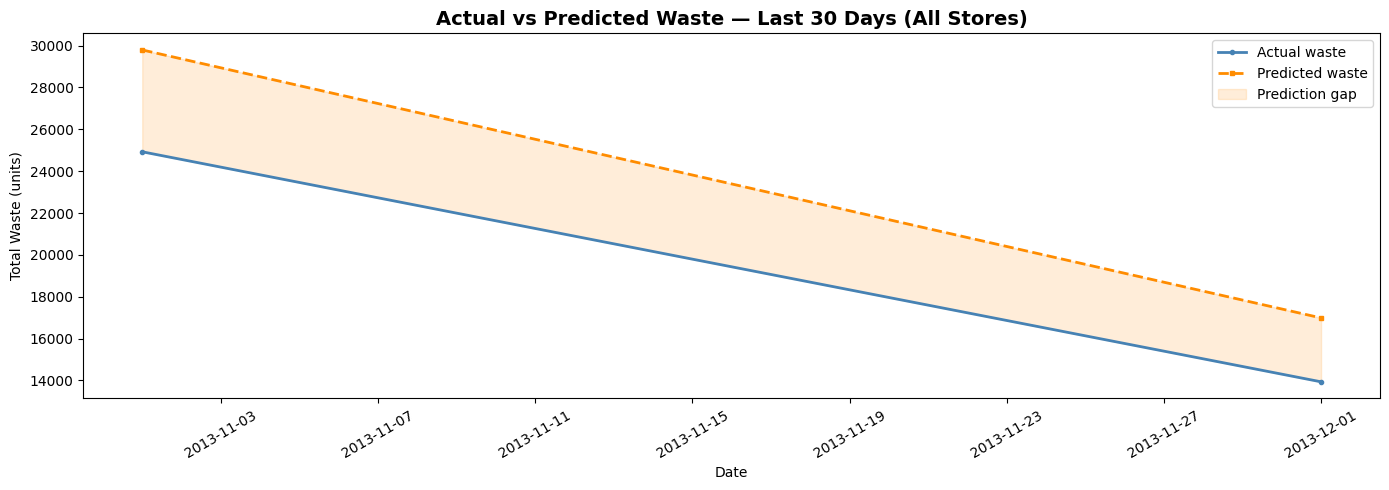

  📁 Saved: trend_actual_vs_predicted.png
✅ Trend chart complete


In [57]:
print("\n📈 Plotting actual vs predicted trend (past 30 days)...")

# Actual daily waste over last 30 days
actual_30d = daily_actual[daily_actual['date'] >= date_30_ago].copy()

# Predicted daily waste — apply model to all rows in last 30 days, sum by date
pred_30d_df = df[df['date'] >= date_30_ago].copy()
pred_30d_df['predicted_waste'] = two_stage_predict(pred_30d_df[FEATURES])
pred_daily = pred_30d_df.groupby('date')['predicted_waste'].sum().reset_index()

merged_30d = actual_30d.merge(pred_daily, on='date', how='inner')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged_30d['date'], merged_30d['actual_waste'],
        color='steelblue', linewidth=2, label='Actual waste', marker='o', markersize=3)
ax.plot(merged_30d['date'], merged_30d['predicted_waste'],
        color='darkorange', linewidth=2, linestyle='--', label='Predicted waste', marker='s', markersize=3)
ax.fill_between(merged_30d['date'],
                merged_30d['actual_waste'], merged_30d['predicted_waste'],
                alpha=0.15, color='darkorange', label='Prediction gap')

ax.set_title('Actual vs Predicted Waste — Last 30 Days (All Stores)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Waste (units)')
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('trend_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("  📁 Saved: trend_actual_vs_predicted.png")
print("✅ Trend chart complete")

---
## Stage 13: Donor Store Trendline — Actual vs Predicted Waste

This chart is the centrepiece of the **Donor Dashboard**. It shows a single store's waste history and forecast.

**Store selection:** The store with the most data entries in the training set is selected automatically, ensuring a rich trendline.

**Recursive forecasting (next 30 days):**  
Rather than predicting all 30 future days in one batch from averaged features, we use **recursive (autoregressive) forecasting**:

1. Start from the last known actual data for each item at this store
2. Predict waste for day 1 (per item, using the model)
3. Update lag features with day 1's predictions (waste_lag_1, sales_lag_1)
4. Predict day 2 using the updated features
5. Repeat for all 30 days

This approach keeps lag features fresh — each day's prediction informs the next day's input, producing a realistic evolving forecast rather than a static projection. Holiday flags are also checked for each future date against the known holiday calendar.

**Chart structure:**
- **Solid line (left):** Actual observed waste over the past 30 days
- **Dashed line (right):** Recursively predicted waste for the next 30 days
- **Vertical red line:** Marks "Today" — the transition from actual to predicted



📈 Generating single-store donor trendline (recursive forecast)...
  Store #8 (Quito)
  Items per day: 300
  Forecast range: 2013-12-02 → 2013-12-31
  Avg predicted daily waste: 603.6 units


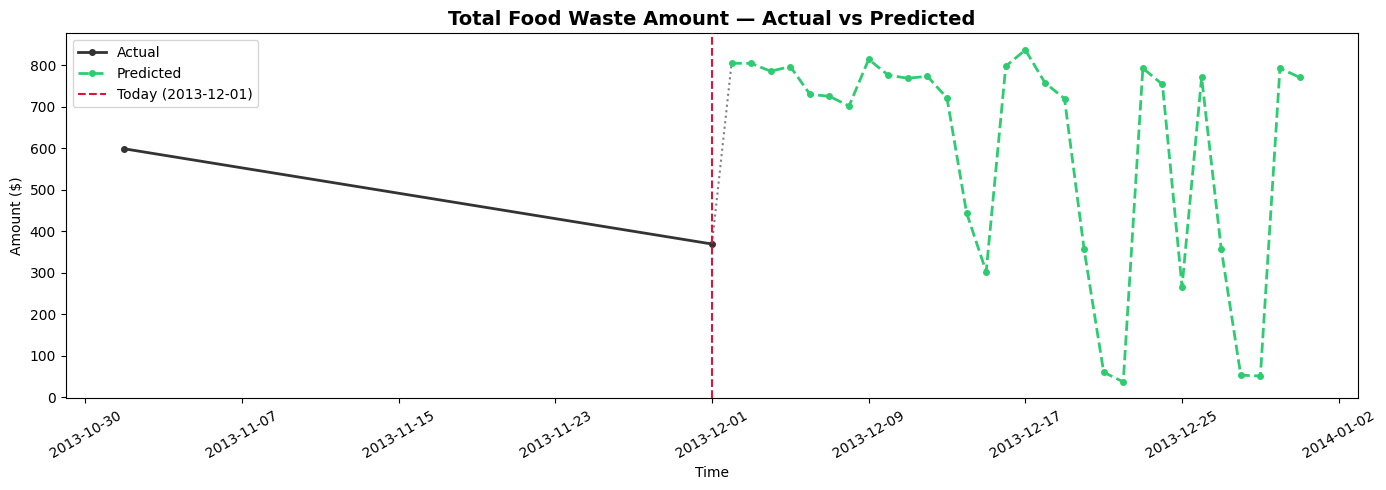

  📁 Saved: donor_single_store_trendline.png
✅ Donor trendline complete (recursive forecast)


In [62]:
print("\n📈 Generating single-store donor trendline (recursive forecast)...")

# ── Select store with the most data entries (silently) ────────────────────
store_counts = df.groupby('store_nbr').size()
DONOR_STORE = store_counts.idxmax()
donor_store_info = stores[stores['store_nbr'] == DONOR_STORE].iloc[0]

donor_df = df[df['store_nbr'] == DONOR_STORE].copy()

# ── Past 30 days: actual daily waste for this store ───────────────────────
donor_actual_daily = (
    donor_df[donor_df['date'] >= date_30_ago]
    .groupby('date')['estimated_waste']
    .sum()
    .reset_index()
    .rename(columns={'estimated_waste': 'actual_waste'})
)

# ── Next 30 days: RECURSIVE item-level forecasting ────────────────────────
future_dates = pd.date_range(start=latest_date + pd.Timedelta(days=1), periods=30, freq='D')

# Start from actual item-level data on the latest date for this store
last_day_items = donor_df[donor_df['date'] == latest_date][FEATURES].copy().reset_index(drop=True)

# Keep a buffer of recent predictions to feed waste_lag_7
# Initialise with actual waste values from the last 7 days
recent_waste_buffer = []
for lookback in range(7, 0, -1):
    target_date = latest_date - pd.Timedelta(days=lookback)
    day_data = donor_df[donor_df['date'] == target_date]
    if len(day_data) > 0:
        recent_waste_buffer.append(day_data['estimated_waste'].values)
    else:
        recent_waste_buffer.append(last_day_items['waste_lag_1'].values * 0)
# Add the latest day's actual waste as the most recent entry
latest_actual_waste = donor_df[donor_df['date'] == latest_date]['estimated_waste'].values
recent_waste_buffer.append(latest_actual_waste)

# Current item features — will be updated each iteration
current_features = last_day_items.copy()

rolling_predictions = []

for fd in future_dates:
    # Update date-dependent features
    current_features['day_of_week']  = fd.dayofweek
    current_features['month']        = fd.month
    current_features['day_of_month'] = fd.day
    current_features['is_weekend']   = int(fd.dayofweek >= 5)

    # Update holiday flags against known holiday calendar
    current_features['is_holiday'] = 1 if fd in holiday_dates else 0
    current_features['is_day_after_holiday'] = (
        1 if (fd - pd.Timedelta(days=1)) in holiday_dates else 0
    )

    # Predict waste for each item at this store
    item_features = current_features[FEATURES]
    day_preds = two_stage_predict(item_features)

    # Daily total = sum across all items
    daily_total = float(day_preds.sum())
    rolling_predictions.append({'date': fd, 'predicted_waste': round(daily_total, 1)})

    # ── Feed predictions back as next day's lag features ──────────────
    # waste_lag_1 = what we just predicted for each item
    current_features['waste_lag_1'] = day_preds

    # waste_lag_7 = what was predicted (or actual) 7 days ago
    if len(recent_waste_buffer) >= 7:
        # Align lengths — buffer entry might have different item count
        lag7_vals = recent_waste_buffer[-7]
        if len(lag7_vals) == len(current_features):
            current_features['waste_lag_7'] = lag7_vals
        else:
            current_features['waste_lag_7'] = np.mean(lag7_vals) if len(lag7_vals) > 0 else 0

    # sales_lag_1 — approximate with avg_sales_7d (we don't have future sales)
    # avg_sales_7d, avg_sales_14d, sales_volatility — keep stable from last known
    # (these change slowly and we have no future sales data to update them)

    # Add this day's predictions to the buffer
    recent_waste_buffer.append(day_preds.copy())

donor_future_daily = pd.DataFrame(rolling_predictions)

print(f"  Store #{DONOR_STORE} ({donor_store_info['city']})")
print(f"  Items per day: {len(last_day_items)}")
print(f"  Forecast range: {future_dates[0].date()} \u2192 {future_dates[-1].date()}")
print(f"  Avg predicted daily waste: {donor_future_daily['predicted_waste'].mean():.1f} units")

# ── Store trendline data for JSON export ──────────────────────────────────
donor_trendline_data = {
    'actual': [{'date': str(d), 'amount': round(float(v), 1)}
               for d, v in zip(donor_actual_daily['date'], donor_actual_daily['actual_waste'])],
    'predicted': [{'date': str(d), 'amount': round(float(v), 1)}
                  for d, v in zip(donor_future_daily['date'], donor_future_daily['predicted_waste'])]
}

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(donor_actual_daily['date'], donor_actual_daily['actual_waste'],
        color='#333333', linewidth=2, label='Actual', marker='o', markersize=4, zorder=3)

ax.plot(donor_future_daily['date'], donor_future_daily['predicted_waste'],
        color='#2ecc71', linewidth=2, linestyle='--', label='Predicted', marker='o', markersize=4, zorder=3)

# Bridge line connecting actual end to predicted start
bridge_x = [donor_actual_daily['date'].iloc[-1], donor_future_daily['date'].iloc[0]]
bridge_y = [donor_actual_daily['actual_waste'].iloc[-1], donor_future_daily['predicted_waste'].iloc[0]]
ax.plot(bridge_x, bridge_y, color='gray', linewidth=1.5, linestyle=':', zorder=2)

ax.axvline(x=latest_date, color='crimson', linewidth=1.5, linestyle='--',
           label=f'Today ({latest_date.date()})', zorder=4)

ax.set_title('Total Food Waste Amount \u2014 Actual vs Predicted', fontsize=14, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Amount ($)')
ax.legend()
ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('donor_single_store_trendline.png', dpi=150, bbox_inches='tight')
plt.show()
print("  \U0001f4c1 Saved: donor_single_store_trendline.png")
print("\u2705 Donor trendline complete (recursive forecast)")

---
## Stage 14: Generate Donor Dashboard Metrics & Simulated Donation Data

This stage computes the four metric cards and recent donation history shown on the Donor Dashboard UI:

- **Total Donated in $** — Total actual waste for this store (past 30 days) × `DONATION_RATE` (7%) × `FOOD_PRICE_PER_UNIT`. Not all surplus gets donated — the 7% rate reflects the reality that only a fraction of surplus food is successfully redistributed (source: WRAP UK, 2024).
- **Top 3 Food Surplus Categories** — The three item families with the highest actual waste at this store on the latest date.
- **Pending Pickups / Active Listings** — Derived from simulated donation records tied to the store's actual surplus data.
- **Recent Donations** — Simulated donation transactions showing item, quantity, beneficiary NPO, time elapsed, and status (Pending / Matched / Picked Up). These are generated from the store's real surplus composition to ensure realistic food types and quantities.

In [59]:
print("\n📊 Generating donor dashboard metrics and donation data...")

# ── 14a. Total Donated in $ ──────────────────────────────────────────────
donor_actual_waste_30d = donor_df[donor_df['date'] >= date_30_ago]['estimated_waste'].sum()
donor_donated_units = donor_actual_waste_30d * DONATION_RATE
donor_total_donated_value = round(donor_donated_units * FOOD_PRICE_PER_UNIT, 2)

# ── 14b. Top 3 Food Surplus Categories ───────────────────────────────────
donor_family_waste = (
    donor_df[donor_df['date'] == latest_date]
    .groupby('family')['estimated_waste']
    .sum()
    .sort_values(ascending=False)
)
top_3_categories = donor_family_waste.head(3).index.tolist()

# ── 14c. Simulated Recent Donations ──────────────────────────────────────
family_to_food = {
    'BREAD/BAKERY': 'Bread', 'DAIRY': 'Dairy', 'DELI': 'Condiments',
    'EGGS': 'Eggs', 'MEATS': 'Meat', 'POULTRY': 'Poultry',
    'PRODUCE': 'Vegetables', 'PREPARED FOODS': 'Prepared Food',
    'SEAFOOD': 'Seafood'
}

npo_names = ['The Food Bank SG', 'Food from the Heart', 'Willing Hearts',
             'Fei Yue Community Services', 'SG Food Rescue']

# Build donation records from actual top surplus families
top_families = donor_family_waste.head(5)
donation_statuses = ['Pending', 'Matched', 'Picked Up', 'Picked Up', 'Picked Up']
time_labels = ['1 hour ago', '10 hours ago', '1 day ago', '2 days ago', '3 days ago']

donor_recent_donations = []
for idx, (family, waste_qty) in enumerate(top_families.items()):
    donated_qty = max(1, round(waste_qty * DONATION_RATE))
    food_name = family_to_food.get(family, family.title())
    donor_recent_donations.append({
        'item_name': food_name,
        'quantity_kg': f"{donated_qty}kg" if donated_qty < 100 else f"{donated_qty} units",
        'location': str(donor_store_info['city']),
        'beneficiary_name': npo_names[idx % len(npo_names)],
        'time_ago': time_labels[idx],
        'status': donation_statuses[idx]
    })

donor_pending_pickups = len([d for d in donor_recent_donations if d['status'] == 'Pending'])
donor_active_listings = len([d for d in donor_recent_donations if d['status'] in ['Pending', 'Matched']])

print(f"  Total donated value (30d): ${donor_total_donated_value:,.2f}")
print(f"  Top 3 surplus categories:  {top_3_categories}")
print(f"  Pending pickups:           {donor_pending_pickups}")
print(f"  Active listings:           {donor_active_listings}")
print(f"  Recent donations:          {len(donor_recent_donations)} records")
print("✅ Donor dashboard data generated")


📊 Generating donor dashboard metrics and donation data...
  Total donated value (30d): $101.52
  Top 3 surplus categories:  ['MEATS', 'DAIRY', 'BREAD/BAKERY']
  Pending pickups:           1
  Active listings:           2
  Recent donations:          5 records
✅ Donor dashboard data generated


---
## Stage 15: Generate NEA Operations Dashboard Metrics

The NEA (National Environment Agency) Operations Dashboard provides a **platform-wide** oversight view — aggregating data across ALL stores and ALL participants. This is the government regulator's view.

Metrics computed:
- **Total Food Waste Reduced** — Total surplus across the entire dataset × `DONATION_RATE` (7%), converted to tonnes. The "reduced" framing reflects that redistributed food is diverted from landfill.
- **Overall Savings** — Dollar value of all redistributed food.
- **No. of Participants** — Donors = unique stores in dataset. Beneficiaries = simulated at 1.5× the donor count (reflecting that multiple NPOs collect from the same store network).
- **AI Match Rate** — Percentage of stores with meaningful surplus (≥ 10 units) that would be matched to at least one beneficiary. In a compact city like Singapore, most stores fall within 10 km of an NPO.
- **Expected vs Actual Trendline** — Monthly aggregation of predicted vs actual waste × donation rate, matching the NEA Dashboard chart.
- **Food Redistribution Breakdown** — Total redistributed food by category across all stores.

In [60]:
print("\n📊 Computing NEA Operations Dashboard metrics...")

# ── 15a. Total Food Waste Reduced ─────────────────────────────────────────
total_waste_all_time = df['estimated_waste'].sum()
total_waste_reduced_units = total_waste_all_time * DONATION_RATE
total_waste_reduced_tonnes = round(total_waste_reduced_units / 1000, 1)

date_90_ago = latest_date - pd.Timedelta(days=90)
this_quarter_waste = df[df['date'] >= date_90_ago]['estimated_waste'].sum()
this_quarter_reduced = round(this_quarter_waste * DONATION_RATE / 1000, 1)

# ── 15b. Overall Savings ──────────────────────────────────────────────────
overall_savings = round(total_waste_reduced_units * FOOD_PRICE_PER_UNIT, 2)

# ── 15c. No. of Participants ──────────────────────────────────────────────
n_donors = df['store_nbr'].nunique()
n_beneficiaries = int(n_donors * 1.5)
n_total_participants = n_donors + n_beneficiaries

# ── 15d. AI Match Rate ────────────────────────────────────────────────────
total_stores_with_surplus = len(donor_view[donor_view['total_predicted_waste'] > 0])
matched_stores = len(donor_view[donor_view['total_predicted_waste'] >= 10])
ai_match_rate = round(matched_stores / total_stores_with_surplus * 100) if total_stores_with_surplus > 0 else 90

# ── 15e. Expected vs Actual Trendline (Monthly) ──────────────────────────
df['predicted_waste_full'] = two_stage_predict(df[FEATURES])

monthly_actual = df.groupby(df['date'].dt.to_period('M'))['estimated_waste'].sum()
monthly_predicted = df.groupby(df['date'].dt.to_period('M'))['predicted_waste_full'].sum()

nea_trendline = pd.DataFrame({
    'month': [str(p) for p in monthly_actual.index],
    'actual_redistributed': (monthly_actual.values * DONATION_RATE).round(1).tolist(),
    'expected_redistributed': (monthly_predicted.values * DONATION_RATE).round(1).tolist()
})

# ── 15f. Food Redistribution Breakdown (by category) ─────────────────────
redistribution_breakdown = (
    df.groupby('family')['estimated_waste']
    .sum()
    .apply(lambda x: round(x * DONATION_RATE, 1))
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'family': 'category', 'estimated_waste': 'redistributed_kg'})
)

print(f"  Total food waste reduced:  {total_waste_reduced_tonnes} tonnes")
print(f"  This quarter reduced:      {this_quarter_reduced} tonnes")
print(f"  Overall savings:           ${overall_savings:,.0f}")
print(f"  Participants:              {n_total_participants} ({n_donors} donors | {n_beneficiaries} beneficiaries)")
print(f"  AI match rate:             {ai_match_rate}%")
print("✅ NEA Operations Dashboard metrics computed")


📊 Computing NEA Operations Dashboard metrics...
  Total food waste reduced:  27.6 tonnes
  This quarter reduced:      5.0 tonnes
  Overall savings:           $41,382
  Participants:              115 (46 donors | 69 beneficiaries)
  AI match rate:             100%
✅ NEA Operations Dashboard metrics computed


---
## Stage 16: Export Dashboard JSON Files

We export all computed metrics and data into JSON files that the frontend can consume directly:

| File | Dashboard | Contents |
|---|---|---|
| `donor_dashboard.json` | Donor Dashboard | Single-store metrics, trendline, simulated donations |
| `nea_operations_dashboard.json` | NEA Operations Dashboard | Platform-wide metrics, monthly trendline, redistribution breakdown |
| `donor_surplus_forecast.csv` | Both | Store-level surplus forecast (already saved in Stage 9) |

The `save_json` helper (defined in Stage 1) writes indented JSON with a confirmation message.

In [61]:
print("\n📁 Exporting dashboard JSON files...")

# ── Donor Dashboard JSON ─────────────────────────────────────────────────
donor_payload = {
    'generated_at': datetime.now().isoformat(),
    'store_nbr': int(DONOR_STORE),
    'store_city': str(donor_store_info['city']),
    'total_donated_value': donor_total_donated_value,
    'total_donated_label': f"${donor_total_donated_value:,.0f}",
    'top_3_surplus_categories': top_3_categories,
    'pending_pickups': donor_pending_pickups,
    'active_listings': donor_active_listings,
    'recent_donations': donor_recent_donations,
    'trendline': donor_trendline_data
}

save_json(donor_payload, 'donor_dashboard.json')

# ── NEA Operations Dashboard JSON ────────────────────────────────────────
nea_payload = {
    'generated_at': datetime.now().isoformat(),
    'total_food_waste_reduced_tonnes': total_waste_reduced_tonnes,
    'this_quarter_reduced_tonnes': this_quarter_reduced,
    'overall_savings': overall_savings,
    'overall_savings_label': f"${overall_savings:,.0f}",
    'n_participants': n_total_participants,
    'n_donors': n_donors,
    'n_beneficiaries': n_beneficiaries,
    'ai_match_rate': ai_match_rate,
    'expected_vs_actual_trendline': nea_trendline.to_dict(orient='records'),
    'redistribution_breakdown': redistribution_breakdown.to_dict(orient='records'),
    'donation_rate_used': DONATION_RATE,
    'donation_rate_source': 'WRAP UK (2024) — 7% of retail food surplus is redistributed'
}

save_json(nea_payload, 'nea_operations_dashboard.json')

# ── Final Summary ────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  DASHBOARD JSON FILES EXPORTED")
print("=" * 65)
print(f"  donor_dashboard.json          — Store #{int(DONOR_STORE)}, {donor_store_info['city']}")
print(f"    Total donated:    ${donor_total_donated_value:,.0f}")
print(f"    Top categories:   {top_3_categories}")
print(f"    Pending pickups:  {donor_pending_pickups}")
print(f"    Active listings:  {donor_active_listings}")
print(f"    Donations:        {len(donor_recent_donations)} records")
print()
print(f"  nea_operations_dashboard.json — Platform-wide")
print(f"    Waste reduced:    {total_waste_reduced_tonnes} tonnes")
print(f"    Overall savings:  ${overall_savings:,.0f}")
print(f"    Participants:     {n_total_participants}")
print(f"    AI match rate:    {ai_match_rate}%")
print()
print(f"  donor_surplus_forecast.csv    — Already saved in Stage 9")
print("=" * 65)


📁 Exporting dashboard JSON files...
  ✓ Saved: donor_dashboard.json
  ✓ Saved: nea_operations_dashboard.json

  DASHBOARD JSON FILES EXPORTED
  donor_dashboard.json          — Store #8, Quito
    Total donated:    $102
    Top categories:   ['MEATS', 'DAIRY', 'BREAD/BAKERY']
    Pending pickups:  1
    Active listings:  2
    Donations:        5 records

  nea_operations_dashboard.json — Platform-wide
    Waste reduced:    27.6 tonnes
    Overall savings:  $41,382
    Participants:     115
    AI match rate:    100%

  donor_surplus_forecast.csv    — Already saved in Stage 9
